# Sensors, Signals, and Surveillance

This hackathon is about turning your phone into a sensor array and seeing what you can learn from the naturalistic (i.e., unlabelled) data it produces. Because nothing is labelled, this is a nice sandbox for unsupervised learning (clustering, dimensionality reduction, anomaly detection) as well as more hands-on feature engineering and signal processing.

It's also directly relevant to computational cognitive science: behavior (movement, activity, attention) leaves traces in exactly this kind of sensor data, and turning raw signals into interpretable features is a core skill in that field. Beyond that, you'll get to practice data cleaning, time-series handling, visualization, and (if you want to go further) building your own classifiers.

**Getting the data**
- [Phyphox (PH)](https://phyphox.org/wiki/index.php/Main_Page) exports a zip per recording containing one CSV per sensor plus a `meta/` folder. It supports more sensor types (magnetometer, pressure, light, etc.) and tends to give more reliable GPS. However, it only records while your screen is on, and you cannot adjust sampling frequency.
- [Physics Toolbox (PT)](https://www.vieyrasoftware.net/tutorial) exports a single CSV per recording. Simpler to work with, but fewer sensors. What is nice, though, is that it records offline and allows custom sampling frequencies. You'll have to install the 'Pro Version' though - which I luckily have cracked for us :)

**What's provided here:** loaders for both formats into one common DataFrame, column standardization, downsampling, and a few example analyses (plotting, basic feature extraction, GPS trajectories, frequency analysis).

**What you can do:** record your own data (e.g., walking vs. running, commuting, working vs. resting), extend the feature extraction, build and evaluate a classifier, or design a small experiment around your own research question.

## Setup and Imports

In [ ]:
# imports
import pandas as pd
import numpy as np
import zipfile # for reading raw phyphox exports
import glob
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt


# I recommend downsampling for long-ish recordings (anything above 1min honestly) or for macro-level analysis (e.g., activity recognition, movement analysis, etc.)
DOWNSAMPLING = True
TARGET_FS = 50 # Hz, target sampling frequency (when downsampling)

## Data Loading and Cleaning

This section loads every file in `/data` into one big DataFrame (one loader for PT `.csv` files, one for PH `.zip` exports), tags each recording with a `file_id`, and lines up timestamps into two common time columns. `timestamp` is a readable absolute datetime; `time` is numeric seconds relative to the shared `TIME_ORIGIN`, which makes recordings from different subjects directly comparable. By the end, `df` has one row per timestamp per subject, with all sensor columns alongside `file_id`.

In [144]:
# get all file paths in the /data directory
data_dir = Path.cwd() / "data" 
file_paths = glob.glob(str(data_dir / "*"))

# all csv files are physics toolbox (PT), all zip files are phyphox (PH)
pt_files = [path for path in file_paths if path.endswith(".csv")]
ph_files = [path for path in file_paths if path.endswith(".zip")]
pt_files = ['C:\\Users\\malte\\Documents\\iiccsss\\hacks\\sensors_and_signals\\data\\pt_2026-08-2014.53.05.csv']

# simply use the data type with most files available (change manually if needed)
if len(pt_files) >= len(ph_files):
	DATA_TYPE = "PT"
	print(f"Automatically selecting Physics Toolbox (PT) data type (CSV) with {len(pt_files)} files.")
	n_files = len(pt_files)
else:
	DATA_TYPE = "PH"
	print(f"Automatically selecting Phyphox (PH) data type (ZIP) with {len(ph_files)} files.")
	n_files = len(ph_files)


### Manual Override
DATA_TYPE = "PT" # "PH"  # or "PT" for physics toolbox


Automatically selecting Phyphox (PH) data type (ZIP) with 2 files.


### Note
We assume 1 file per subject (id); the data loaders automatically name each file 'subj_x' with x being the index in the path list. Of course it can also be repeated trials for similar subjects. If this matters for your analysis, I'd recommend adjusting the naming procedure (perhaps to include the filename in the ID).

PT clock-only recordings are combined with the date embedded in their filename, such as `2026-08-20` in `pt_2026-08-2013.29.13.csv`. Files without a date use `TIME_ORIGIN`'s date. The readable `timestamp` column preserves this absolute time, while numeric `time` stores seconds relative to the shared `TIME_ORIGIN`.

A few other things worth knowing:
- PH sensors are merged onto the timeline of the highest-frequency sensor (usually accelerometer) via `merge_asof` with a 100ms tolerance, so slower sensors (e.g., pressure, light) will have a lot of forward-filled/NaN values in between their actual readings.
- Mixed sampling rates across sensors mean `df` isn't a clean, fixed-interval time series until you downsample - keep that in mind if you skip downsampling.
- If you want to compare across subjects/files directly, the shared numeric time axis now preserves clock-time alignment. For activity-onset alignment instead, add a separate alignment step.

In [145]:
# loads all PT sensor data into a single DataFrame

def concatenate_pt_data(filepaths):
    all_data = []
    for id, filepath in enumerate(filepaths):
        df = pd.read_csv(filepath)
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')] # removes empty cols
        
        # prevent iOS vs Android header mismatch
        time_col = next((c for c in df.columns if 'time' in c.lower()), None)
        if time_col and time_col != 'time':
            df = df.rename(columns={time_col: 'time'})
        
        # fix European Locale Commas for non-time sensors
        for col in df.columns:
            if df[col].dtype == 'object' and col != 'time':
                df[col] = df[col].astype(str).str.replace(',', '.')

        # Convert clock time to an absolute timestamp using the date in the filename.
        if df['time'].astype(str).str.contains(':').any():
            clean_time = df['time'].astype(str).str.replace(r':(\d{3})$', r'.\1', regex=True)
            time_dt = pd.to_datetime(clean_time, errors='coerce', format='%H:%M:%S.%f')
            df['time'] = (time_dt - pd.Timestamp("1900-01-01 00:00:00")).dt.total_seconds()  # Adjusted to a fixed origin for consistency
        else:
            df['time'] = df['time'].astype(str).str.replace(',', '.')
            df['time'] = pd.to_numeric(df['time'], errors='coerce')
            df['timestamp'] = TIME_ORIGIN + pd.to_timedelta(df['time'], unit='s')
            
        df['file_id'] = f"subj_{id + 1}"
        all_data.append(df)
        
    concatenated_df = pd.concat(all_data, ignore_index=True)
    concatenated_df = concatenated_df.dropna(subset=['time'])
    return concatenated_df

In [146]:
# loads all PH sensor data into a single DataFrame

def concatenate_ph_data(filepaths):
	"""
	Concatenates all Phyphox sensor data from multiple ZIP files into a single DataFrame.
	"""
	all_data = []
	
	for id, filepath in enumerate(filepaths):
		with zipfile.ZipFile(filepath, 'r') as z:
			file_names = z.namelist()
			
			sensor_dfs = []
			for file in file_names:
				# only process actual sensor csv's
				if not file.endswith('.csv') or 'meta/' in file:
					continue
				
				with z.open(file) as f:
					sensor_df = pd.read_csv(f)

				if len(sensor_df) == 0:
					print(f'Skipping empty {file} file.')
					continue
					
				# fix time col issues, sort, make columns unique, then append
				if 'Time (s)' in sensor_df.columns:
					sensor_df = sensor_df.rename(columns={'Time (s)': 'time'}) # to be consistent w PT data
					# force time to float64 in case it isn't already
					sensor_df['time'] = pd.to_numeric(sensor_df['time'], errors='coerce')
					sensor_df = sensor_df.dropna(subset=['time'])
					sensor_df = sensor_df.sort_values('time')
					
					sensor_dfs.append(sensor_df)
					
			if not sensor_dfs:
				raise ValueError(f"No valid sensor CSV files found in {filepath}.")
			
			# sort df by length (descending) so we use the highest-frequency 
			# sensor (usually acc) as our base time axis.
			sensor_dfs.sort(key=len, reverse=True)
			
			# iteratively merge all sensors onto the base timeline.
			# tolerance=0.1 means if a slower sensor doesn't have a reading within 
			# 100ms of the fast sensor, it will log as NaN (Not a Number) for that row.
			df = sensor_dfs[0]
			for next_df in sensor_dfs[1:]:
				df = pd.merge_asof(df, next_df, on='time', direction='nearest', tolerance=0.1)

			# create file id column
			df['file_id'] = f"subj_{id + 1}"

			all_data.append(df)

	return pd.concat(all_data, ignore_index=True)

In [147]:
# create the df
if DATA_TYPE == 'PT':
	df = concatenate_pt_data(pt_files)
elif DATA_TYPE == 'PH':
	df = concatenate_ph_data(ph_files)
else:
	raise ValueError("DATA_TYPE must be 'PH' or 'PT'")

In [148]:
df.head()

,time,ax,ay,az,wx,wy,wz,Gain,Latitude,Longitude,Speed (m/s),file_id
0,53585.319,0.0,0.0,0.0,0.0000,0.0000,0.0000,-∞,0.000000,0.000000,0.0,subj_1
1,53585.337,0.0,0.0,0.0,0.0000,0.0000,0.0000,-∞,48.526011,9.063965,0.0,subj_1
2,53585.383,0.0,0.0,0.0,0.1075,-0.0244,0.0264,-∞,48.526011,9.063965,0.0,subj_1
3,53585.387,0.0,0.0,0.0,0.1075,-0.0244,0.0264,-∞,48.526011,9.063965,0.0,subj_1
4,53585.387,0.0,0.0,0.0,0.1075,-0.0244,0.0264,-∞,48.526011,9.063965,0.0,subj_1


### Normalizing Column Names

I think most of the column names are too wordy, especially for PH data, so I'll rename them (but you can skip this step).

In [149]:
# for renaming Phyphox (PH) data
PH_RENAME_DICT = {
    'time': 'time',
    'Acceleration x (m/s^2)_x': 'acc_x',
    'Acceleration y (m/s^2)_x': 'acc_y',
    'Acceleration z (m/s^2)_x': 'acc_z',
    'Gyroscope x (rad/s)': 'gyr_x',
    'Gyroscope y (rad/s)': 'gyr_y',
    'Gyroscope z (rad/s)': 'gyr_z',
    'Linear Acceleration x (m/s^2)': 'lin_acc_x',
    'Linear Acceleration y (m/s^2)': 'lin_acc_y',
    'Linear Acceleration z (m/s^2)': 'lin_acc_z',
    'w': 'quat_w',
    'x': 'quat_x',
    'y': 'quat_y',
    'z': 'quat_z',
    'Direct (°)': 'direction',
    'Yaw (°)': 'yaw',
    'Pitch (°)': 'pitch',
    'Roll (°)': 'roll',
    'Acceleration x (m/s^2)_y': 'acc_x_alt',
    'Acceleration y (m/s^2)_y': 'acc_y_alt',
    'Acceleration z (m/s^2)_y': 'acc_z_alt',
    'Magnetic field x (µT)': 'mag_x',
    'Magnetic field y (µT)': 'mag_y',
    'Magnetic field z (µT)': 'mag_z',
    'Pressure (hPa)': 'pressure',
    'Illuminance (lx)': 'light',
    'Distance (cm)': 'distance',
    'Speed (m/s)': 'speed',
	'Direction (°)': 'direction',
    'Latitude (°)': 'lat',
    'Horizontal Accuracy (m)': 'horizontal_accuracy',
    'Longitude (°)': 'lon',
    'Vertical Accuracy (m)': 'vertical_accuracy',
    'Altitude (m)': 'alt',
    'Altitude WGS84 (m)': 'alt_wgs84', # this is the altitude relative to the WGS84 ellipsoid, which is a standard reference for GPS coordinates
    'Distance (km)': 'distance_km',
    'Satellites': 'satellites',
    'file_id': 'file_id'
}

# for renaming Physics Toolbox (PT) data
PT_RENAME_DICT = {
    'time': 'time',
    'ax': 'acc_x',
    'ay': 'acc_y',
    'az': 'acc_z',
    'wx': 'gyr_x',
    'wy': 'gyr_y',
    'wz': 'gyr_z',
    'I': 'light',
    'Gain': 'gain',
    'Latitude': 'lat',
    'Longitude': 'lon',
    'Speed (m/s)': 'speed',
    'file_id': 'file_id'
}

def standardize_columns(df, data_type):
    """
    Renames DataFrame columns based on the DATA_TYPE ('PH' or 'PT').
    """
    dt = data_type.upper()
    if dt == 'PH':
        return df.rename(columns=PH_RENAME_DICT)
    elif dt == 'PT':
        return df.rename(columns=PT_RENAME_DICT)
    else:
        raise ValueError("DATA_TYPE must be 'PH' or 'PT'")


In [150]:
# standardize column names
df = standardize_columns(df, DATA_TYPE)

### Downsampling

We should downsample in most cases, especially for long recordings.

Each file is resampled independently to a fixed interval (`1/TARGET_FS` seconds) by averaging within each bin and forward-filling any gaps. This turns the irregularly-sampled, per-sensor timeline from the loaders into a clean, regular time series that's much easier (and faster) to plot, filter, and run FFTs on. Set `DOWNSAMPLING = False` above if you need the original sampling rate (e.g., for very short or high-frequency recordings).

In [ ]:
if DOWNSAMPLING:
    df_time = df.copy()
    
    # Ensure time is numeric and create the time index
    df_time['time'] = pd.to_numeric(df_time['time'], errors='coerce')
    df_time['time_dt'] = pd.to_timedelta(df_time['time'], unit='s')
    df_time = df_time.set_index('time_dt')
    
    interval = pd.Timedelta(seconds=1.0 / TARGET_FS)

    # Replace numeric and string infinity values before selecting numeric columns.
    if 'gain' in df_time.columns:
        df_time['gain'] = pd.to_numeric(
            df_time['gain'].replace({'-∞': np.nan, '∞': np.nan}),
            errors='coerce'
        )
    
    # Define a helper function to resample each file individually
    def resample_file(group):
        numeric_cols = group.select_dtypes(include='number').columns
        # Resample and immediately forward-fill to fix the empty rows
        resampled = group[numeric_cols].resample(interval).mean().ffill()
        return resampled
    
    # Apply the resampling grouped by file_id (group_keys defaults to True)
    df_resampled = df_time.groupby('file_id').apply(resample_file, include_groups=False)
    
    # The groupby operation moves file_id and time_dt into a MultiIndex; reset it
    df = df_resampled.reset_index()
    
    # Recreate the standard numeric time column and drop the datetime object
    df['time'] = df['time_dt'].dt.total_seconds()
    df = df.drop(columns=['time_dt'])

In [152]:
df.head()

,file_id,time,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,gain,lat,lon,speed
0,subj_1,53585.319,0.0,0.0,0.0,0.0000,0.0000,0.0000,NaN,24.263005,4.531983,0.0
1,subj_1,53585.339,0.0,0.0,0.0,0.0000,0.0000,0.0000,NaN,24.263005,4.531983,0.0
2,subj_1,53585.359,0.0,0.0,0.0,0.0000,0.0000,0.0000,NaN,24.263005,4.531983,0.0
3,subj_1,53585.379,0.0,0.0,0.0,0.1075,-0.0244,0.0264,NaN,48.526011,9.063965,0.0
4,subj_1,53585.399,0.0,0.0,0.0,0.1075,-0.0244,0.0264,NaN,48.526011,9.063965,0.0


## Exploration - Plotting

Before doing anything fancy, it's worth just looking at the data: check value ranges (do they look physically plausible?), spot missing values or gaps, and get a feel for how noisy/clean a given sensor is across subjects.

`plot_sensor_cols()` below is a general-purpose helper for plotting any column(s) against time, for one or more files, with the option to average across files. Extend it by adding your own preprocessing (e.g., smoothing, normalization) before plotting, or by plotting distributions (histograms, boxplots) instead of raw time series.

In [63]:
# utility function for plotting a subset of columns and files against time

def plot_sensor_cols(df, columns, time_col='time', title="Sensor Data Over Time", 
                     render_step=1, files=[], average_over_files=False):
    """
    Plots specified DataFrame columns against time.
    
    Parameters:
    - df: pandas DataFrame containing the data.
    - columns: string or list of strings representing the columns to plot.
    - time_col: string, name of the time column (default 'time').
    - title: string, title of the plot.
    - render_step: int, downsamples rendering speed (e.g., render_step=5 plots every 5th point).
    - files: list of strings, specific files to plot (e.g., ['subj_1', 'subj_2']). Empty list plots all.
    - average_over_files: bool, if True, averages the column values across all selected files at each time step.
    """
    if isinstance(columns, str):
        columns = [columns]
        
    if time_col not in df.columns:
        raise ValueError(f"Time column '{time_col}' not found in DataFrame.")

    # filter by selected files if the list is not empty
    df_plot = df.copy()
    if files and 'file_id' in df_plot.columns:
        df_plot = df_plot[df_plot['file_id'].isin(files)]

    plt.figure(figsize=(12, 5))
    
    # averaging across files
    if average_over_files:
        # Group by the time column to get the mean of the aligned time bins
        df_avg = df_plot.groupby(time_col, as_index=False)[columns].mean()
        df_avg = df_avg.iloc[::render_step] # Apply render step after averaging
        
        for col in columns:
            plt.plot(df_avg[time_col], df_avg[col], label=f"{col} (Average)", alpha=0.8, linewidth=1.5)
            
    # individual file plotting (if not averaging)
    else:
        df_plot = df_plot.iloc[::render_step]
        for file, group in df_plot.groupby('file_id'):
            for col in columns:
                if col in group.columns:
                    plt.plot(group[time_col], group[col], label=f"{col} ({file})", alpha=0.8, linewidth=1.2)
                else:
                    print(f"Warning: Column '{col}' not found in DataFrame.")


    plt.xlabel(f"{time_col} (s)")
    plt.ylabel("Sensor Reading")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc="upper right", framealpha=0.9)
    plt.tight_layout()
    plt.show()

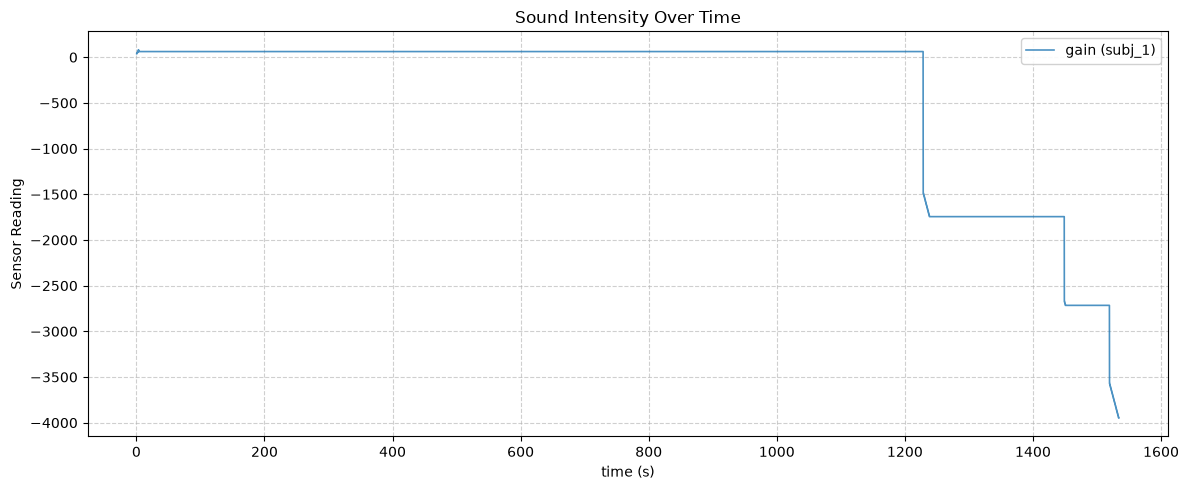

In [64]:
# example for plotting one type of sensor data over time
cols = ['gain'] # columns of sensor data that we're interested in
subjs = ['subj_1']  # specify files to plot, or leave empty for all
plot_sensor_cols(df, cols, title="Sound Intensity Over Time", files=subjs)

## Basic Feature Extraction

Plotting raw data (especially for multiple files) can get messy quickly. We can use summary statistics to make this a bit easier.

Feature extraction turns a raw, high-dimensional time series into a handful of numbers that summarize what's actually happening (e.g., "how much movement", "how variable"), which makes downstream comparison, clustering, or classification much more tractable than working with raw samples.

Below we compute overall acceleration magnitude and its rolling variance, but there's plenty more you could add: rolling mean/std of other sensors, jerk (derivative of acceleration), zero-crossing rate, min/max/range per window, or frequency-domain features (see the frequency analysis section further down).

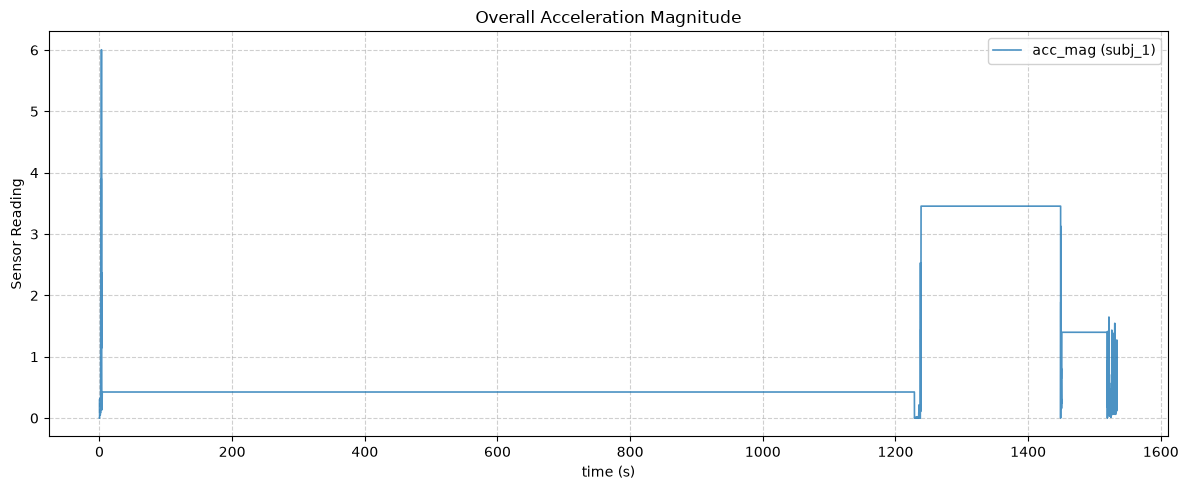

In [65]:
# we can do a bit of feature extraction and compute total 3D magnitude movement (e.g., acc or gyr)

# using euclidean norm (sqrt(x^2 + y^2 + z^2)) for acceleration; can be useful for activity recognition or movement analysis
df['acc_mag'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

# file 5 data contains walking and running movement over 50s (i'm lazy, ok)
plot_sensor_cols(df, columns=['acc_mag'], title="Overall Acceleration Magnitude", files=['subj_1'])

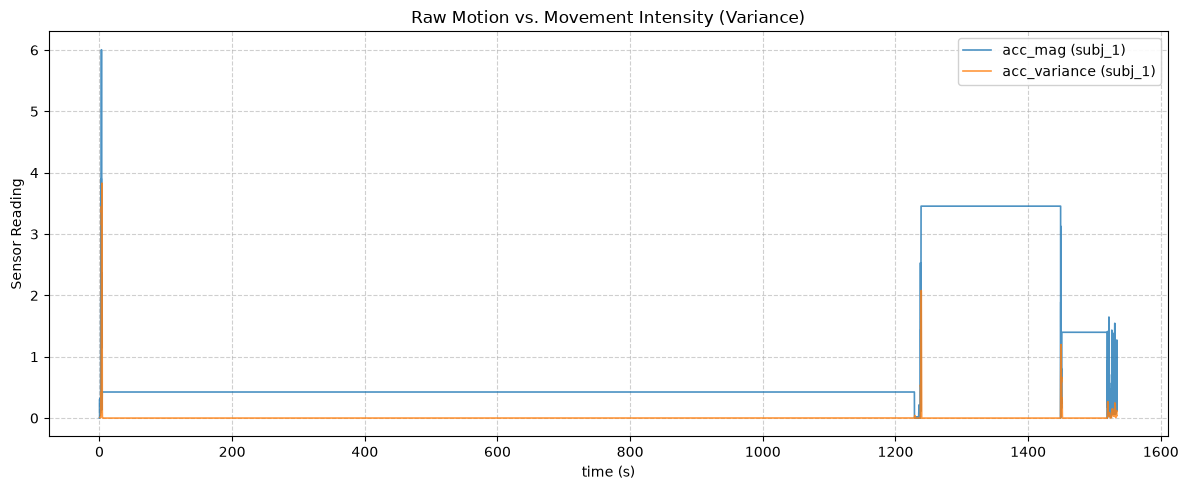

In [66]:
# similarly, we can compute variance over a rolling window to quantify movement intensity
WINDOW_SIZE = TARGET_FS 

df['acc_variance'] = df.groupby('file_id')['acc_mag'].rolling(window=WINDOW_SIZE).var().reset_index(drop=True)

plot_sensor_cols(df, columns=['acc_mag', 'acc_variance'], title="Raw Motion vs. Movement Intensity (Variance)", files=['subj_1'])

### Observations / Suggestions

Variance tracks changes in movement intensity fairly well, but the window size matters a lot - too short and it's noisy, too long and it smears over transitions (e.g., start/stop of walking). Try comparing a couple of `WINDOW_SIZE` values, or compute variance on `lin_acc` instead of raw `acc` if your data has it (removes the gravity component).

## Location Tracking

fun fact: PH is better for location tracking

This section plots GPS coordinates (lat/lon) as a 2D trajectory, colored by elapsed time, so you can see not just where someone went but in what order / how fast. Location data opens up its own set of questions: commute/movement patterns, speed profiles (derived from consecutive GPS points or the `speed` column), time spent in different areas, or combining GPS with accelerometer data to distinguish, e.g., walking from being in a vehicle.

In [67]:
# utility function for plotting GPS trajectory over time

def plot_gps_trajectory(df, lat_col='lat', lon_col='lon', time_col='time', title="GPS Trajectory Over Time", render_step=1, files=[]):
    """
    Plots Latitude and Longitude on a 2D spatial map, colored by time.
    Automatically splits by file.
    """
    if lat_col not in df.columns or lon_col not in df.columns:
        raise ValueError(f"Columns '{lat_col}' and/or '{lon_col}' not found in DataFrame.")
    
    cmap = plt.get_cmap('viridis_r')  # reversed viridis for time coloring
	
    # filter by selected files if provided
    df_plot = df.copy()

    # remove (0,0) points (caused by invalid readings) to avoid skewing the plot
    df_plot = df_plot[(df_plot[lat_col] != 0) & (df_plot[lon_col] != 0)]
    
    if files and 'file_id' in df_plot.columns:
        df_plot = df_plot[df_plot['file_id'].isin(files)]

    # downsample
    df_plot = df_plot.iloc[::render_step]
    
    plt.figure(figsize=(10, 8))
    
    # plot each file's trajectory
    if 'file_id' in df_plot.columns:
        for file, group in df_plot.groupby('file_id'):
            # skip nans
            group_clean = group.dropna(subset=[lat_col, lon_col, time_col])
            
            if group_clean.empty:
                print(f"Warning: No valid GPS data for file '{file}'. Skipping.")
                continue
                
            # gray connection lne
            plt.plot(group_clean[lon_col], group_clean[lat_col], color='gray', alpha=0.4, linewidth=1)
            
            # time-colored scatter points
            scatter = plt.scatter(
                group_clean[lon_col], group_clean[lat_col], 
                c=group_clean[time_col], cmap=cmap, 
                label=file, s=20, alpha=0.9, zorder=3
            )
    else:
        # if no file_id exists for whatever reason
        df_clean = df_plot.dropna(subset=[lat_col, lon_col, time_col])
        plt.plot(df_clean[lon_col], df_clean[lat_col], color='gray', alpha=0.4, linewidth=1)
        scatter = plt.scatter(
            df_clean[lon_col], df_clean[lat_col], 
            c=df_clean[time_col], cmap=cmap, s=20, alpha=0.9, zorder=3
        )

    # longitude: x, latitude: y
    cbar = plt.colorbar(scatter)
    cbar.set_label(f"Elapsed Time ({time_col} in seconds)")
    
    plt.xlabel(f"Longitude ({lon_col})")
    plt.ylabel(f"Latitude ({lat_col})")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.6)
    
    if 'file_id' in df_plot.columns:
        plt.legend(loc="best", framealpha=0.9)
        
    plt.tight_layout()
    plt.show()


### Note

If there are 0,0 values (PT data placeholders), they will be removed when plotting (they are most likely invalid readings, unless you record somewhere in Africa). We can use additional filters to remove other invalid readings by setting them to NaN. PH data specifically includes accuracy measures (but I don't know how they work) and satellite count (which is pretty self-explanatory). We can use the latter to filter further (see below). For PT data, good luck.

Also, we plot absolute coordinates, so files that moved far away from each other will appear far apart on the plot (messing up the visualization); If you want to visualize relative movement, consider normalizing the coordinates per file or plotting GPS deltas instead of absolute positions. It could also be fun to see if you can re-create (and improve on) the GPS path using only the accelerometer and gyroscope data.

In [68]:
# when using PH data, we can use additional columns to filter out low-quality GPS readings if needed
if DATA_TYPE == 'PH':
	df.loc[df['satellites'] <=0, ['lat', 'lon']] = np.nan # e.g., no satellites *probably* means invalid GPS reading

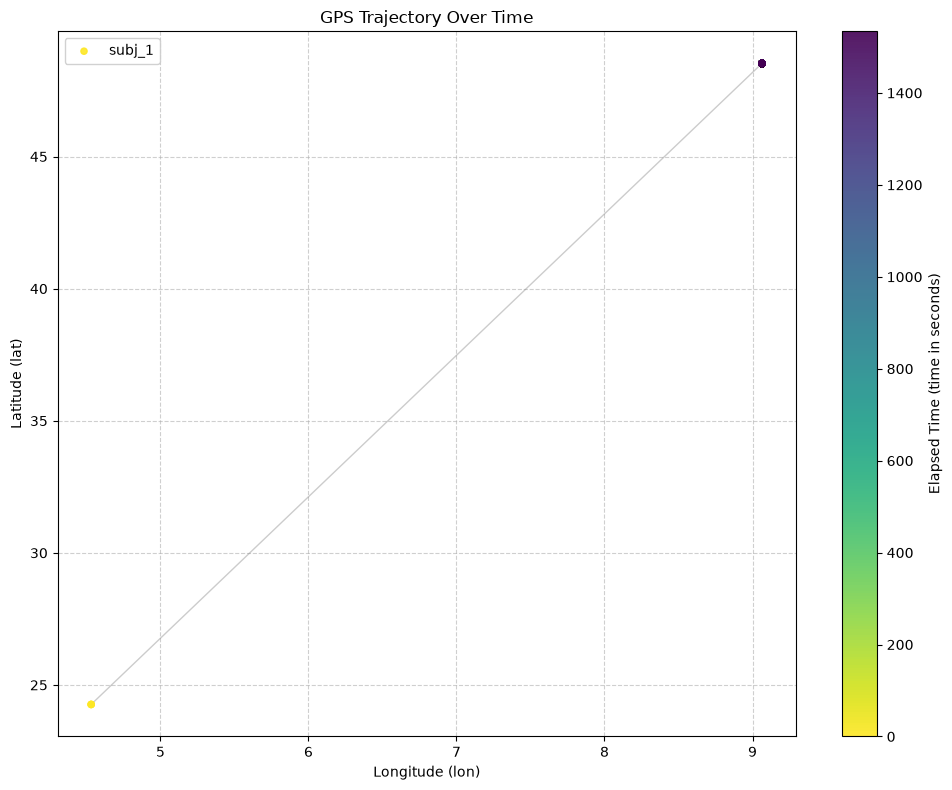

In [69]:
# example plot
plot_gps_trajectory(df, files=['subj_1'], render_step=1)

### Observations / Suggestions

GPS accuracy varies a lot indoors or between buildings, so short "jumps" in the trajectory are often noise rather than real movement - consider filtering by `horizontal_accuracy` (PH) if it's too jumpy. Also, GPS updates much slower than accelerometer/gyroscope, so it's most useful for macro-level movement rather than fine-grained motion analysis.

## Basic Frequency Analysis

Movement (and a lot of other behavior) is often periodic - think steps while walking/running, or vibration patterns - and periodicity is much easier to spot in frequency space than in the raw time-domain signal. This section computes the FFT of a sensor column (per file) and plots its amplitude spectrum, so you can look for dominant frequencies that might indicate repetitive movement.

This can reveal things regular plotting can't: e.g., that "noisy-looking" acceleration data actually has a clear dominant frequency around ~1.5-2.5Hz, consistent with walking/running cadence. You could extend this with a spectrogram (frequency content over time, useful for recordings with multiple activities), band-power features, or by applying it to other sensors (e.g., gyroscope for rotational movement).

In [70]:
# utility function to plot the frequency spectrum of a single sensor column

def plot_frequency_spectrum(df, column, fs, title=None, files=[]):
    """
    Computes and plots the frequency spectrum of a given sensor column.
    
    Parameters:
    - df: pandas DataFrame containing the data.
    - column: string, the sensor column to analyze (e.g., 'acc_mag').
    - fs: int or float, the sampling frequency in Hz.
    - files: list of strings, specific files to plot. Empty list plots all.
    """
    df_plot = df.copy()
    
    # filter
    if files and 'file_id' in df_plot.columns:
        df_plot = df_plot[df_plot['file_id'].isin(files)]
        
    plt.figure(figsize=(10, 4))
    
    # iterate over specified files
    if 'file_id' in df_plot.columns:
        for file, group in df_plot.groupby('file_id'):
            signal = group[column].dropna().values
            if len(signal) == 0:
                continue
                
            # Subtract mean and compute FFT
            signal_centered = signal - np.mean(signal) # removes DC component
            n = len(signal_centered)
            fft_amplitudes = np.abs(np.fft.rfft(signal_centered)) / n 
            frequencies = np.fft.rfftfreq(n, d=1.0/fs)
            
            plt.plot(frequencies, fft_amplitudes, alpha=0.8, linewidth=1.5, label=f"{column} ({file})")
    else:
        # in case of single-file df without file_id column
        signal = df_plot[column].dropna().values
        if len(signal) > 0:
            signal_centered = signal - np.mean(signal)
            n = len(signal_centered)
            fft_amplitudes = np.abs(np.fft.rfft(signal_centered)) / n 
            frequencies = np.fft.rfftfreq(n, d=1.0/fs)
            
            plt.plot(frequencies, fft_amplitudes, color='purple', linewidth=1.5, label=column)

    plt.title(title if title else f"Frequency Spectrum of {column}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xlim(0, min(10, fs/2)) 
    plt.legend(loc="upper right", framealpha=0.9)
    plt.tight_layout()
    plt.show()


C:\Users\malte\AppData\Local\Temp\ipykernel_12352\3049639386.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", framealpha=0.9)


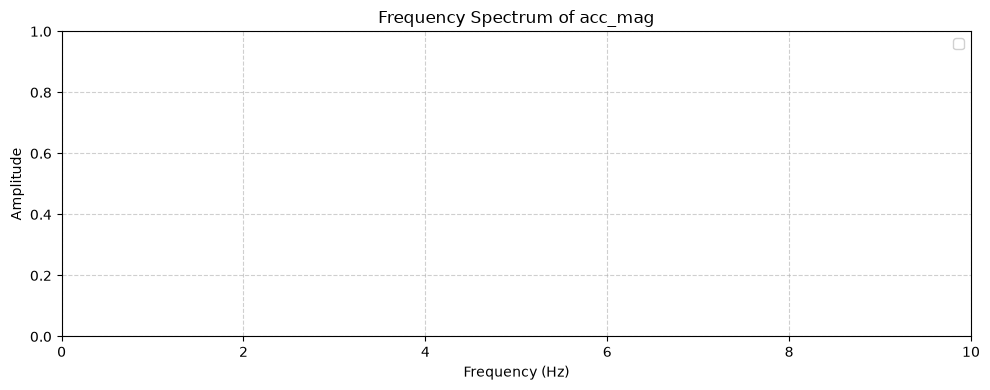

In [71]:
plot_frequency_spectrum(df, column='acc_mag', fs=TARGET_FS, files=['subj_5'])

### Note

Depending on which file you choose, you can observe distinct peaks at various frequency values. Naively, we can assume that different kinds of behavior has different characteristic (/dominant) frequency. We can build such a naive activity classifier and evaluate that assumption below. Keep in mind that frequency data is more reliable for longer recordings.

In [72]:
# helper function to extract a dominant frequency from a 1d signal
def get_dominant_freq(signal, fs, variance_threshold=0.15):
    """
    Extracts the dominant frequency, but only if the signal has enough energy 
    to be considered actual movement.
    """
    # threshold noise (somewhat arbitrarily)
    if np.var(signal) < variance_threshold:
        return np.nan  # return nan to indicate noise
        
    # if above noise threshold, use fft
    signal_centered = signal - np.mean(signal)
    fft_amplitudes = np.abs(np.fft.rfft(signal_centered)) # using rfft for real value signal
    frequencies = np.fft.rfftfreq(len(signal_centered), d=1.0/fs)
    
    return frequencies[np.argmax(fft_amplitudes)] # index returned freqs at max amplitude  

# maps dominant freq to numeric activity estimate (again, pretty arbitrarily)
def map_activity_numeric(freq):
    if np.isnan(freq):
        return np.nan
    elif freq > 2.0:
        return 2 # running
    elif freq > 1.0:
        return 1  # waling
    else:
        return 0  # resting 

# rolling window calculation
WINDOW_SECONDS = 3
WINDOW_SIZE = int(WINDOW_SECONDS * TARGET_FS)

# add dominant_freq column to df (raw=True speeds this up by using numpy arrays)
df['dominant_freq'] = df['acc_mag'].rolling(window=WINDOW_SIZE).apply(
    lambda x: get_dominant_freq(x, TARGET_FS), raw=True
)

# numeric classification
df['predicted_activity'] = df['dominant_freq'].apply(map_activity_numeric) * 10 # scaling up only for visualization only


C:\Users\malte\AppData\Local\Temp\ipykernel_12352\620883263.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right", framealpha=0.9)


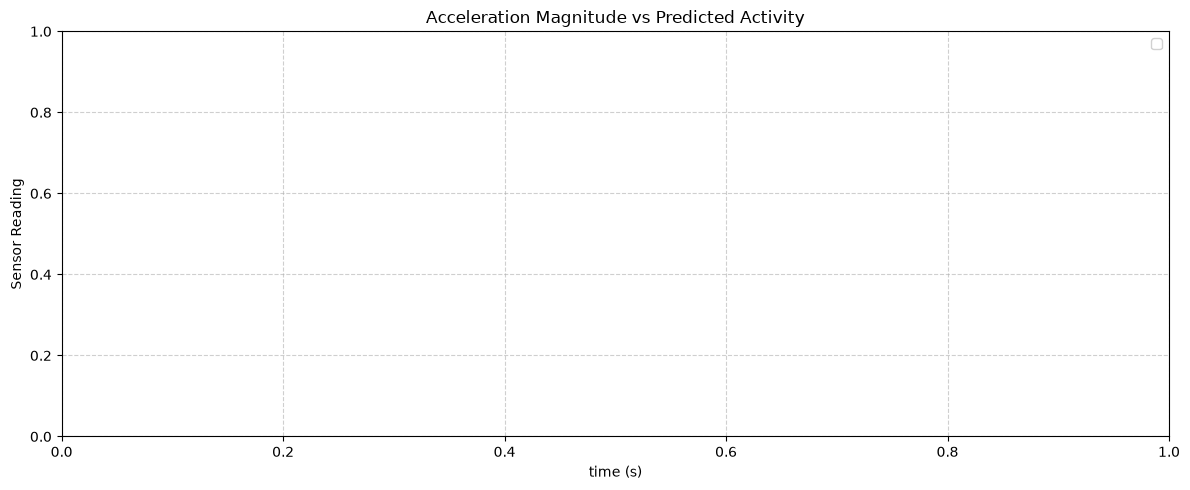

In [73]:
# plot using our trusty function
plot_sensor_cols(
    df, 
    columns=['acc_mag', 'predicted_activity', 'dominant_freq'], 
    title="Acceleration Magnitude vs Predicted Activity",
    files=['subj_5']
)

### Observation / Suggestion

This classifier is super trashy, and even if we hack it to work for this data, it most likely wont generalize to any other data - there are much smarter ways of building it. Maybe you can think of some?

## Conclusion & Where to Go From Here

You now have a clean, merged DataFrame with time-aligned sensor data, some basic plots, some simple features, and a (very rough) frequency-based activity classifier. From here, there are a lot of directions you could do, depending on what you're interested in, for example:

- **Gait analysis**: use the accelerometer/gyroscope data to detect individual steps (e.g., peak detection on `acc_mag`) and derive metrics like step count, cadence (steps/min), stride regularity, or left-right asymmetry. This is a classic application of phone sensors in movement/health research and pairs nicely with the frequency analysis section above.
- **Unsupervised learning / dimensionality reduction**: since our data is unlabelled, techniques like PCA, t-SNE, or UMAP on windowed features (e.g., mean/variance/dominant frequency per window) can reveal natural groupings in the data - do different activities or subjects separate out without ever telling the model what they were doing? Clustering (k-means, DBSCAN, hierarchical) on the same features could then give you data-driven "activity types" to compare against your own intuition.
- **Social cluster analysis (GPS)**: if multiple subjects recorded at the same time, you could look for spatial/temporal co-occurrence (e.g., subjects who were within some distance of each other at the same time) to infer social proximity or shared movement patterns, and represent this as a network/graph for further analysis (e.g., community detection).
- **Sensor fusion**: combine accelerometer + gyroscope (+ magnetometer, if available) to estimate orientation or reconstruct a movement path, and compare it against the actual GPS trajectory - how far off do you get using only inertial sensors?
- **Activity/context classification**: build a proper classifier (rather than our frequency-threshold hack) using windowed features and a model like random forest or a simple neural net, ideally validated against some form of ground truth (e.g., a self-logged activity diary).
- **Environmental/behavioral correlations**: relate movement or location data to other sensors (light, pressure, magnetic field) - e.g., does light level predict indoor/outdoor transitions, or does pressure track floor changes in a building?
- **A (Moral) Narrative**: imagine someone malicious had access to your sensor data like that. What might they be able to infer about you? How could this information be used and who might be interested in having it? Think about the ethics of sensor data collection and analysis, and how to protect privacy in a world where our phones (and watches and whatnot) are constantly collecting data. Perhaps a nice low-coding alternative to the above.

Whatever direction you pick, the general workflow stays the same: load and clean the data, extract meaningful features, and use those features (rather than raw signals) for your analysis, modeling, or visualization. Think about how you can communicate thoes results well. 

Most importantly, have fun! :)